In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

In [9]:
movies = pd.read_csv('../data/wiki_movie_plots_deduped.csv')

# Quick peek:
print("Shape:", movies.shape)
print("\nColumns:", movies.columns.tolist())
print("\nFirst 5 rows:")
movies.head()

Shape: (34886, 8)

Columns: ['Release Year', 'Title', 'Origin/Ethnicity', 'Director', 'Cast', 'Genre', 'Wiki Page', 'Plot']

First 5 rows:


,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot
0,1901,Kansas Saloon Smashers,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Kansas_Saloon_Sm...,"A bartender is working at a saloon, serving dr..."
1,1901,Love by the Light of the Moon,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Love_by_the_Ligh...,"The moon, painted with a smiling face hangs ov..."
2,1901,The Martyred Presidents,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/The_Martyred_Pre...,"The film, just over a minute long, is composed..."
3,1901,"Terrible Teddy, the Grizzly King",American,Unknown,NaN,unknown,"https://en.wikipedia.org/wiki/Terrible_Teddy,_...",Lasting just 61 seconds and consisting of two ...
4,1902,Jack and the Beanstalk,American,"George S. Fleming, Edwin S. Porter",NaN,unknown,https://en.wikipedia.org/wiki/Jack_and_the_Bea...,The earliest known adaptation of the classic f...


In [10]:
# Basic data info
print("Data Types:")
print(movies.dtypes)

# Amount of missing values
print("\nMissing Values:")
print(movies.isnull().sum())

# Top 10 Genres?
print("\nTop 10 Genres:")
print(movies["Genre"].value_counts().head(10))

# Bottom 10 Genres?
print("\nBottom 10 Genres:")
print(movies["Origin/Ethnicity"].value_counts().tail(10))

# Top 10 Origins (Ethnicities)?
print("\nTop 10 Origins:")
print(movies["Origin/Ethnicity"].value_counts().head(10))


Data Types:
Release Year        int64
Title                 str
Origin/Ethnicity      str
Director              str
Cast                  str
Genre                 str
Wiki Page             str
Plot                  str
dtype: object

Missing Values:
Release Year           0
Title                  0
Origin/Ethnicity       0
Director               0
Cast                1422
Genre                  0
Wiki Page              0
Plot                   0
dtype: int64

Top 10 Genres:
Genre
unknown      6083
drama        5964
comedy       4379
horror       1167
action       1098
thriller      966
romance       923
western       865
crime         568
adventure     526
Name: count, dtype: int64

Bottom 10 Genres:
Origin/Ethnicity
Russian        232
Marathi        141
Filipino       128
Bangladeshi     87
Punjabi         84
Malaysian       70
Turkish         70
Egyptian        67
Assamese         9
Maldivian        2
Name: count, dtype: int64

Top 10 Origins:
Origin/Ethnicity
American      17377
Br

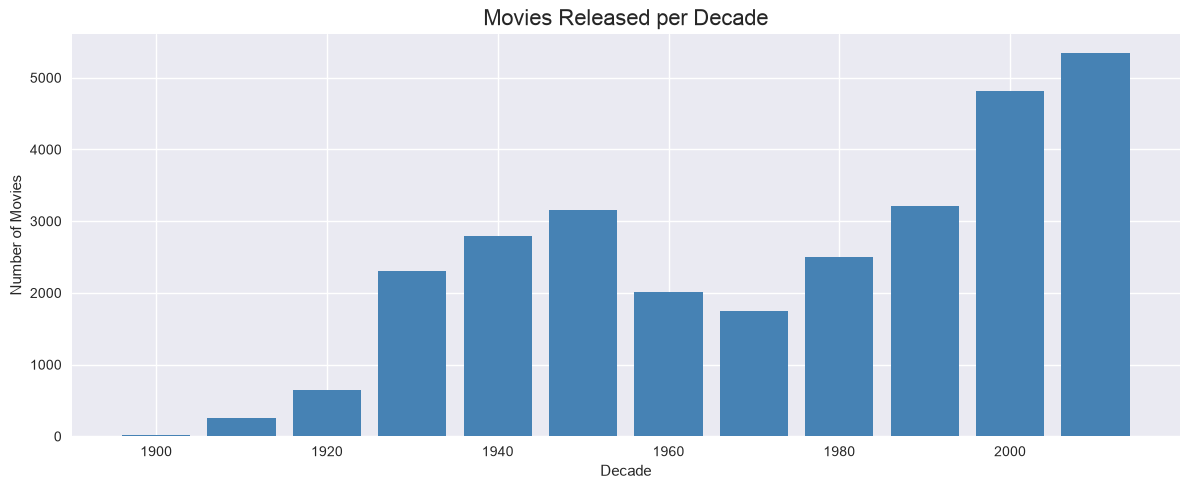

In [14]:
# Visualization 1: Movies released per decade
movies_clean = movies[movies['Genre'] != 'unknown'].copy()
movies_clean['Decade Released'] = (movies_clean['Release Year'] // 10) * 10

decade_counts = movies_clean.groupby('Decade Released').size()

fig, ax = plt.subplots(figsize=(12, 5))
plt.bar(decade_counts.index, decade_counts.values, color = "steelblue", width = 8)
plt.title("Movies Released per Decade", fontsize = 16)
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig('../images/movies_per_decade.png', dpi = 150)

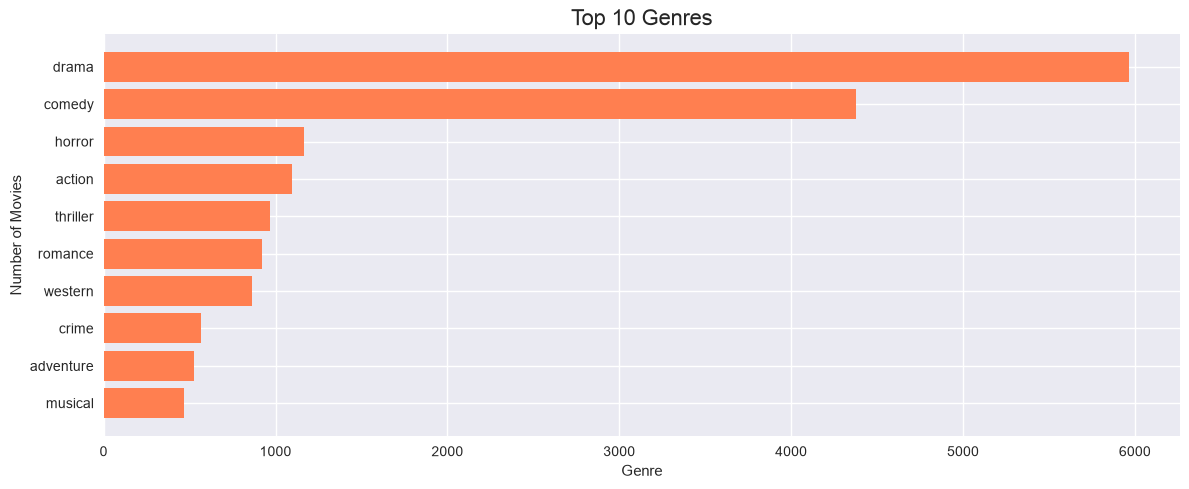

In [15]:
# Visualization 2: Top 10 Genres
genre_counts = movies_clean['Genre'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(genre_counts.index, genre_counts.values, color = "coral")
ax.set_title("Top 10 Genres", fontsize = 16)
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Movies")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../images/top_10_genres.png', dpi = 150)
plt.show()

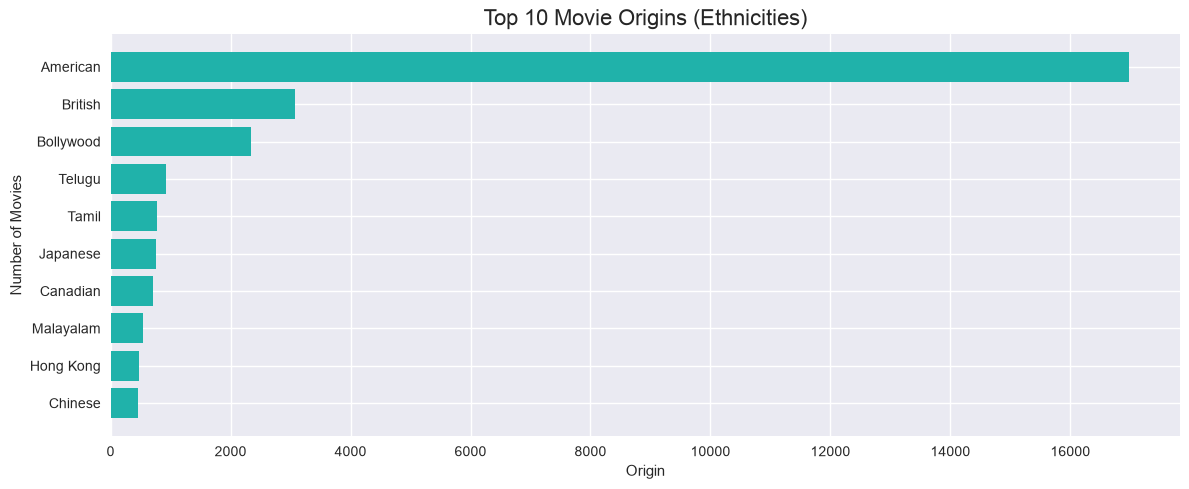

In [16]:
# Visualization 3: Top 10 Movie Origin/Ethnicities
origin_counts = movies_clean['Origin/Ethnicity'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(origin_counts.index, origin_counts.values, color = "lightseagreen")
ax.set_title("Top 10 Movie Origins (Ethnicities)", fontsize = 16)
ax.set_xlabel("Origin")
ax.set_ylabel("Number of Movies")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../images/top_10_origins.png', dpi = 150)
plt.show()